<a href="https://colab.research.google.com/github/riccimason99/Assignment_3_DSCI_631/blob/main/DSCI_631_assignment3_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSCI 631 - Assignment 3 - Question 2
## CNN Image Classification on Vegetable Dataset

In [ ]:
# Import required libraries
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Download and get path to the dataset
dataset_path = kagglehub.dataset_download(
    "misrakahmed/vegetable-image-dataset"
)

# Navigate the directory structure
train_dir = os.path.join(dataset_path, "Vegetable Images", "train")
valid_dir = os.path.join(dataset_path, "Vegetable Images", "validation")
test_dir = os.path.join(dataset_path, "Vegetable Images", "test")

Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.


## Question 2-1:
Examine the dataset, what is the size of each image (how many pixels/channels in each dimension)? Are all the images have the same size?

Describe the dataset directory structure, use coding to count how many images are there in each class for train set, validation set and test set?

Visualize one sample image from each class in train set.

In [ ]:
def examine_dataset(data_dir, set_name):
    """Examine dataset structure and image properties"""
    print(f"\n{set_name} Set Analysis:")
    print("-" * 40)

    class_counts = {}
    all_sizes = set()
    image_mode = None  # Add this

    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            class_counts[class_name] = len(images)

            for img_file in images[:5]:
                img_path = os.path.join(class_path, img_file)
                img = keras.preprocessing.image.load_img(img_path)
                all_sizes.add(img.size)
                if image_mode is None:
                    image_mode = img.mode  # Get mode from PIL: 'RGB', 'RGBA', etc.

    print(f"Classes found: {len(class_counts)}")
    print(f"Image sizes found: {all_sizes}")
    print(f"Image mode: {image_mode}")  # Add this line
    print("\nImages per class:")
    total = 0
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} images")
        total += count
    print(f"Total images in {set_name}: {total}")

    return class_counts, all_sizes, image_mode

In [ ]:
# Examine all three sets
train_counts, train_sizes, train_img_mode = examine_dataset(train_dir, "Training")
valid_counts, valid_sizes, valid_img_mode = examine_dataset(valid_dir, "Validation")
test_counts, test_sizes, test__img_mode = examine_dataset(test_dir, "Test")


Training Set Analysis:
----------------------------------------
Classes found: 15
Image sizes found: {(224, 224)}
Image mode: RGB

Images per class:
  Bean: 1000 images
  Bitter_Gourd: 1000 images
  Bottle_Gourd: 1000 images
  Brinjal: 1000 images
  Broccoli: 1000 images
  Cabbage: 1000 images
  Capsicum: 1000 images
  Carrot: 1000 images
  Cauliflower: 1000 images
  Cucumber: 1000 images
  Papaya: 1000 images
  Potato: 1000 images
  Pumpkin: 1000 images
  Radish: 1000 images
  Tomato: 1000 images
Total images in Training: 15000

Validation Set Analysis:
----------------------------------------
Classes found: 15
Image sizes found: {(224, 224)}
Image mode: RGB

Images per class:
  Bean: 200 images
  Bitter_Gourd: 200 images
  Bottle_Gourd: 200 images
  Brinjal: 200 images
  Broccoli: 200 images
  Cabbage: 200 images
  Capsicum: 200 images
  Carrot: 200 images
  Cauliflower: 200 images
  Cucumber: 200 images
  Papaya: 200 images
  Potato: 200 images
  Pumpkin: 200 images
  Radish: 200 i

**Answer - Dataset description**
- The dataset directory contains 3 folders for the training set, validation set, and test set.
- Each of these folders have subdirectories for the 15 classes that contain images of different vegetables.
- All images are 224 x 224 pixels with 3 channels (RGB)
- The training set folder has 15,000 images (1000 for each of the 15 vegetable classes). The validation set folder has 3,000 images (200 for each vegetable). The test set has 3,000 images (200 for each vegetable). Therefore the train set contains 72% of the total images in the data set, while the validation and test sets contain 14% each.
- The proportion of the 15 vegetable classes within the the train, validation, and test sets is consistent (each class is exactly 1/15 of the total images in that folder).**

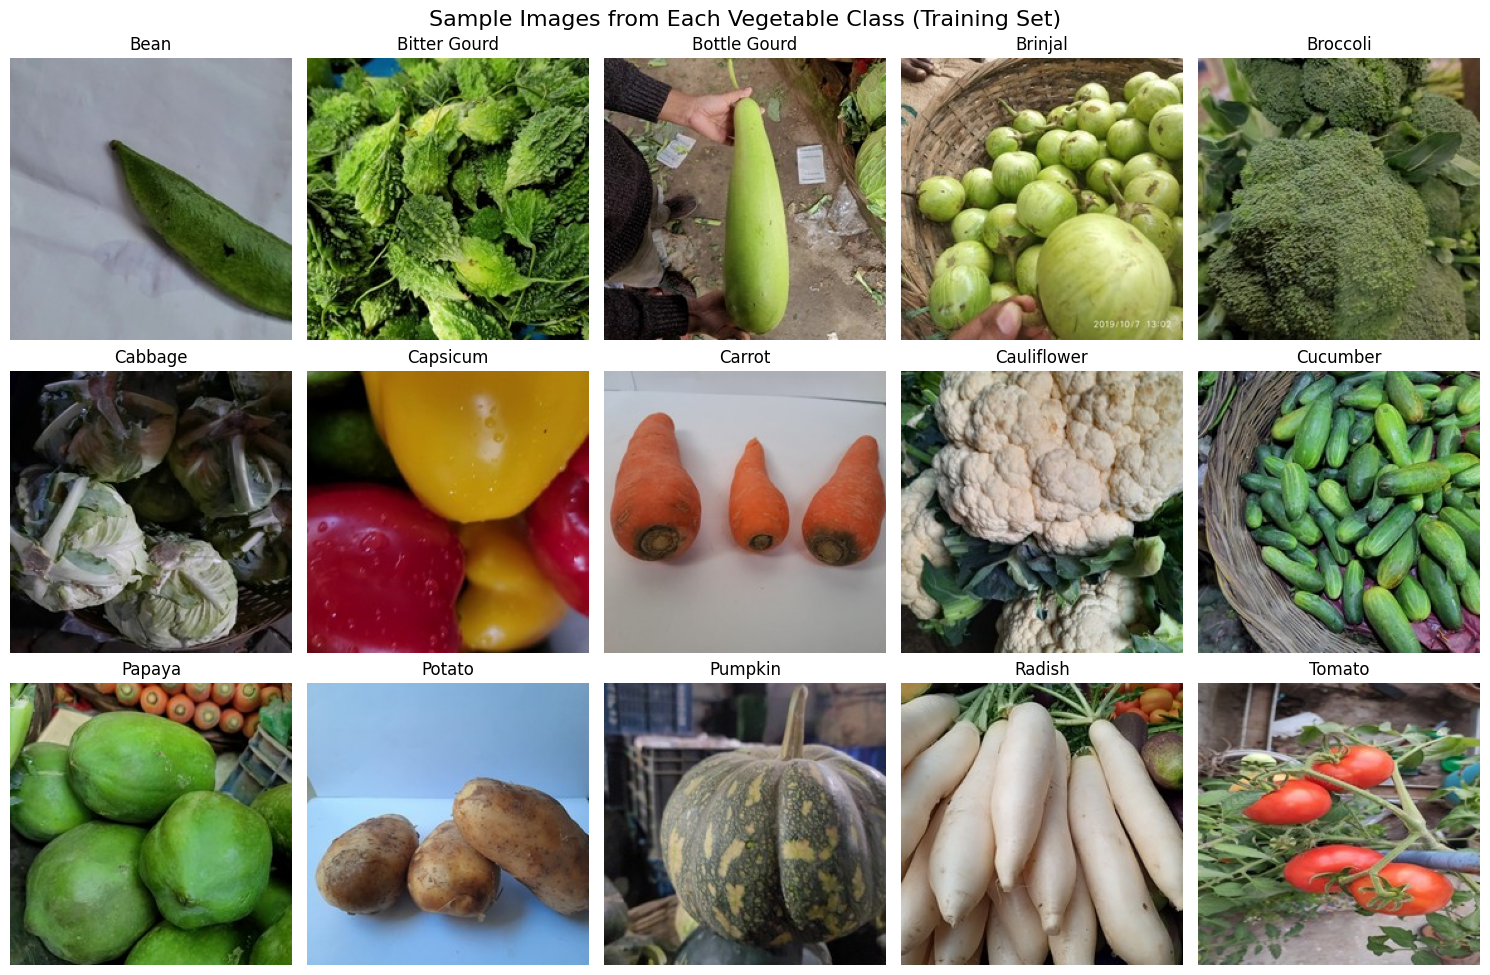

In [ ]:
# Visualize one sample from each class in the training set
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
fig.suptitle('Sample Images from Each Vegetable Class (Training Set)', fontsize=16)

class_names = sorted(os.listdir(train_dir))
for idx, class_name in enumerate(class_names):
    # Get first image from each class
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if images:
        img_path = os.path.join(class_path, images[0])
        img = keras.preprocessing.image.load_img(img_path)

        # Plot image
        row = idx // 5
        col = idx % 5
        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name.replace('_', ' '))
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Question 2-2: Build CNN Model

Build a CNN model with the following:
* Convolution layer with 32 filters of size 3x3, strides of 1, same padding and relu activation function, specify the input_shape
* MaxPooling layer with a pool size of 2
* Convolution layer with 64 filters of size 3x3, strides of 1, same padding and relu activation function
* MaxPooling layer with a pool size of 2
* Flatten layer to flatten the 3 dimensional feature volume
* Dense layer (Fully-connected) with 128 neurons and relu activation function
* Dropout layer with a dropout rate of 25%
* Dense layer (Fully-connected) with 128 neurons and relu activation function
* Final output layer with neuron number the same as class number of the dataset, and softmax activation function

For each layer, how many parameters will be trained? Show your calculation instead of just `model.summary()` only

In [ ]:
# Define the CNN model with the specified architecture
model = Sequential([
    # Layer 1: Conv2D with 32 filters, strides of 1, same padding and relu activation function, input shape specified
    Conv2D(32, (3, 3), strides=(1, 1), padding='same',
           activation='relu', input_shape=(224, 224, 3)),

    # Layer 2: MaxPooling layer with a pool size of 2
    MaxPooling2D(pool_size=(2, 2)),

    # Layer 3: Convolution layer with 64 filters of size 3x3, strides of 1, same padding and relu activation function
    Conv2D(64, (3, 3), strides=(1, 1), padding='same', activation='relu'),

    # Layer 4: MaxPooling layer with a pool size of 2
    MaxPooling2D(pool_size=(2, 2)),

    # Layer 5: Flatten layer to flatten the 3 dimensional feature volume
    Flatten(),

    # Layer 6:  Dense layer (fully-connected) with 128 neurons and relu activation function
    Dense(128, activation='relu'),

    # Layer 7: Dropout layer with a dropout rate of 25%
    Dropout(0.25),

    # Layer 8: Dense layer (fully-connected) with 128 neurons and relu activation function
    Dense(128, activation='relu'),

    # Layer 9: Output layer with 15 classes and and softmax activation function
    Dense(15, activation='softmax')
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,728,079 (98.14 MB)

 Trainable params: 25,728,079 (98.14 MB)

 Non-trainable params: 0 (0.00 B)

**Answer -- Manual Calculation of Trainable Parameters**

**Layer 1 - Conv2D (32 filters, 3x3 kernel):**
- Input shape: 224x224x3
- Parameters = (kernel_height × kernel_width × input_channels × filters) + bias
- Parameters = (3 × 3 × 3 × 32) + 32
- Parameters = 864 + 32 = **896 parameters**

**Layer 2 - MaxPooling2D:**
- No trainable parameters (only pools values, no weights to learn)
- Parameters = **0**

**Layer 3 - Conv2D (64 filters, 3x3 kernel):**
- Input channels: 32 (from previous Conv2D)
- Parameters = (3 × 3 × 32 × 64) + 64
- Parameters = 18,432 + 64 = **18,496 parameters**

**Layer 4 - MaxPooling2D:**
- No trainable parameters
- Parameters = **0**

**Layer 5 - Flatten:**
- No trainable parameters (only reshapes)
- After 2 MaxPooling layers: 224/2/2 = 56
- Output shape: 56 × 56 × 64 = 200,704 neurons
- Parameters = **0**

**Layer 6 - Dense (128 neurons):**
- Input: 200,704 neurons from Flatten
- Parameters = (input_size × output_size) + bias
- Parameters = (200,704 × 128) + 128
- Parameters = 25,690,112 + 128 = **25,690,240 parameters**

**Layer 7 - Dropout (0.25):**
- No trainable parameters (randomly drops neurons during training)
- Parameters = **0**

**Layer 8 - Dense (128 neurons):**
- Input: 128 neurons
- Parameters = (128 × 128) + 128
- Parameters = 16,384 + 128 = **16,512 parameters**

**Layer 9 - Output Dense (15 neurons for 15 classes):**
- Input: 128 neurons
- Parameters = (128 × 15) + 15
- Parameters = 1,920 + 15 = **1,935 parameters**

**TOTAL TRAINABLE PARAMETERS:**
896 + 0 + 18,496 + 0 + 0 + 25,690,240 + 0 + 16,512 + 1,935 = **25,728,079 parameters** which is consistent with model.summary()

## Question 2-3: Train and Evaluate Model

Compile the CNN model with Adam optimizer, categorical_crossentropy loss, and accuracy metrics. Train with train and validation data, then evaluate on test set.

In [ ]:
# Set up data generators with preprocessing
print("Setting up data generators...")

# Create ImageDataGenerator instances with rescaling
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Set batch size
batch_size = 64

# Create data generators using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Setting up data generators...
Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [ ]:
# Compile the model
print("Compiling model...")
model.compile(
    optimizer='adam', #automatically updates weights during training
    loss='categorical_crossentropy', #prediction error measured across all 15 of our classes
    metrics=['accuracy'] #to monitor percentage of correct predictions
)

# Set up early stopping callback if validation loss stops improving for 5 consecutive epochs. Restore weights from best epoch.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

Compiling model...


In [ ]:
# Train the model
print("Starting training...")
print(f"Training configuration:")
print(f"  - Epochs: 35")
print(f"  - Batch size: 64")
print(f"  - Early stopping patience: 5")
print(f"  - Optimizer: Adam")
print(f"  - Loss: categorical_crossentropy")
print("-" * 40)

# Record training time
start_time = time.time()

# Train the model
history = model.fit(
    train_generator,
    epochs=35,
    validation_data=valid_generator,
    callbacks=[early_stopping],
    verbose=1
)

# Calculate training time
end_time = time.time()
training_time = end_time - start_time

print(f"\nTotal training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Actual epochs trained: {len(history.history['loss'])}")

Starting training...
Training configuration:
  - Epochs: 35
  - Batch size: 64
  - Early stopping patience: 5
  - Optimizer: Adam
  - Loss: categorical_crossentropy
----------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 883s 4s/step - accuracy: 0.3080 - loss: 2.6852 - val_accuracy: 0.7843 - val_loss: 0.6781
Epoch 2/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 892s 4s/step - accuracy: 0.8129 - loss: 0.5901 - val_accuracy: 0.8990 - val_loss: 0.3520
Epoch 3/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 881s 4s/step - accuracy: 0.9015 - loss: 0.3115 - val_accuracy: 0.9163 - val_loss: 0.2760
Epoch 4/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 890s 4s/step - accuracy: 0.9415 - loss: 0.1795 - val_accuracy: 0.9140 - val_loss: 0.2811
Epoch 5/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 897s 4s/step - accuracy: 0.9617 - loss: 0.1153 - val_accuracy: 0.8993 - val_loss: 0.3447
Epoch 6/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 878s 4s/step - accuracy: 0.9679 - loss: 0.1069 - val_accuracy: 0.9070 - val_loss: 0.3315
Epoch 7/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 898s 4s/step - accuracy: 0.9706 - loss: 0.0935 - val_accuracy: 0.9187 - val_loss: 0.3469
Epoch 8/35
235/235 ━━━━━━━━━━━━━━━━━━━━ 910s 4s/step - accuracy: 0.9734 - loss: 0.0833 - val_accu

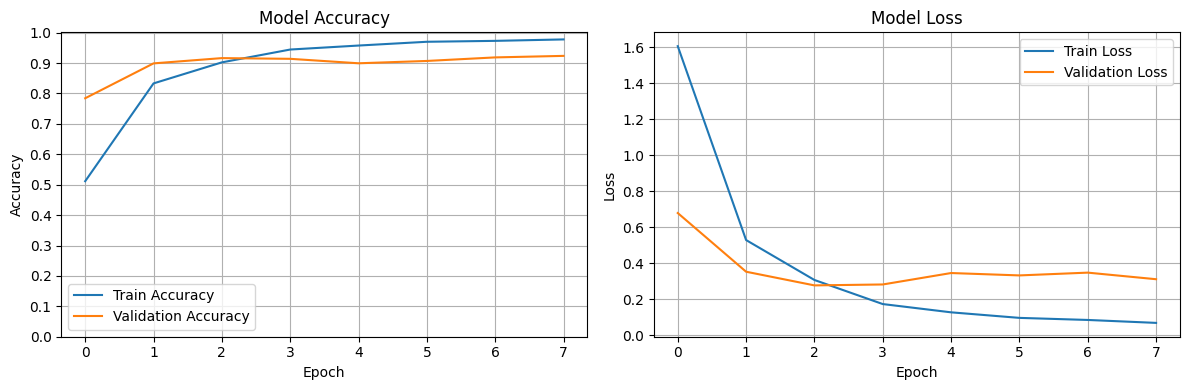

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_yticks(np.arange(0, 1.1, 0.1))
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on test set
print("\n" + "=" * 40)
print("TEST SET EVALUATION")
print("=" * 40)

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Results:")
print(f"  - Test Loss: {test_loss:.4f}")
print(f"  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


TEST SET EVALUATION
47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9201 - loss: 0.2587

Test Results:
  - Test Loss: 0.2711
  - Test Accuracy: 0.9177 (91.77%)


**Answer -- Model Evaluation**

When evaluated on the test set, our model classified the right vegetable class 91.8% of the time. The model's loss (which is what we optimized for) was 0.27 meaning that the model is 73% confident in its classification. It is a strong model but there is still room for improvement. It took 2 epochs of training to determine the optimal model weights. After this point the model started overfitting.
